In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
import warnings
warnings.filterwarnings("ignore")

In [8]:
df_new=pd.read_csv('F:\\ML Projects\\Telecom-Customer-Churn.csv')

In [9]:
pd.set_option('display.max_columns',None)

In [10]:
df_new.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df_new.shape

(7043, 21)

In [12]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
# to check duplicate
df_new.duplicated().sum()

np.int64(0)

In [14]:
df_new['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [15]:
df_new['Churn'].unique()

array(['No', 'Yes'], dtype=object)

#### Note there is imabalance in target column

In [16]:
# Now checking unique values of all the columns
for col in df_new.columns:
    print(col)
    print(df_new[col].unique())
    print('****')

customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
****
gender
['Female' 'Male']
****
SeniorCitizen
[0 1]
****
Partner
['Yes' 'No']
****
Dependents
['No' 'Yes']
****
tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
****
PhoneService
['No' 'Yes']
****
MultipleLines
['No phone service' 'No' 'Yes']
****
InternetService
['DSL' 'Fiber optic' 'No']
****
OnlineSecurity
['No' 'Yes' 'No internet service']
****
OnlineBackup
['Yes' 'No' 'No internet service']
****
DeviceProtection
['No' 'Yes' 'No internet service']
****
TechSupport
['No' 'Yes' 'No internet service']
****
StreamingTV
['No' 'Yes' 'No internet service']
****
StreamingMovies
['No' 'Yes' 'No internet service']
****
Contract
['Month-to-month' 'One year' 'Two year']
****
PaperlessBilling
['Yes' 'No']
****
PaymentM

In [17]:
# Converting TotalCharges to float but there are empty space also 
df_new['TotalCharges']=df_new['TotalCharges'].replace(' ',np.nan)
df_new['TotalCharges']=df_new['TotalCharges'].astype(float)

In [18]:
df_new['TotalCharges'].dtype

dtype('float64')

In [19]:
df_new.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


#### Performing EDA

In [20]:
# Let us perform Univariate Analysis on Numerical columns (SeniorCitizen	tenure	MonthlyCharges	TotalCharges)
# Senior Citizen Column
df_new['SeniorCitizen'].describe()

count    7043.000000
mean        0.162147
std         0.368612
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: SeniorCitizen, dtype: float64

<Axes: ylabel='Frequency'>

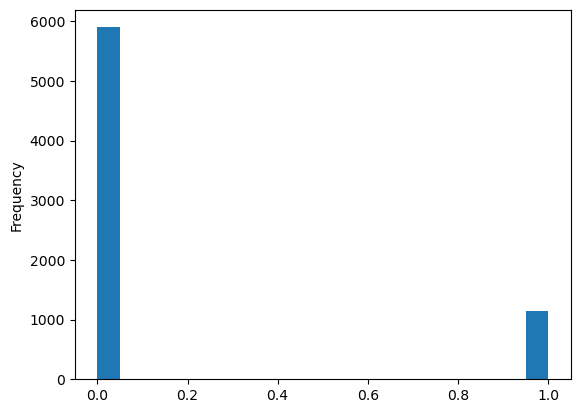

In [21]:
# Visualization
df_new['SeniorCitizen'].plot(kind='hist', bins=20 )

<Axes: ylabel='Density'>

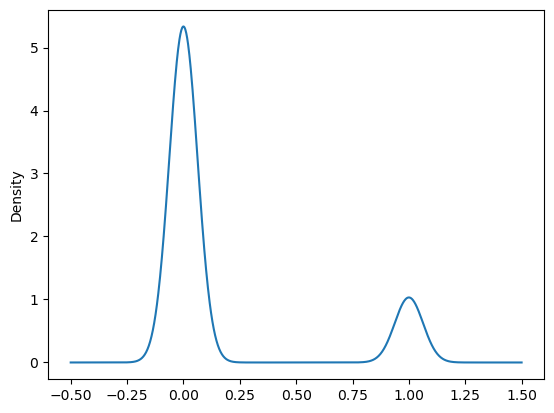

In [22]:
df_new['SeniorCitizen'].plot(kind= 'kde')

In [23]:
df_new['SeniorCitizen'].skew()

np.float64(1.8336327440928564)

<Axes: >

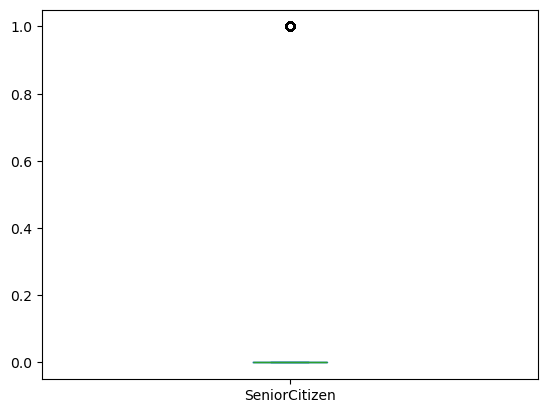

In [24]:
df_new['SeniorCitizen'].plot(kind='box')

In [25]:
df_new['SeniorCitizen'].isnull().sum()*100/len(df_new)

np.float64(0.0)

#### Conclusion - 1) Almost 75% people are not Senior Citizen   2) There are no missing values and no outliers   3) This column is highly positively skewed
            
            

In [26]:
# Analysis on tenure column
df_new['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

<Axes: ylabel='Frequency'>

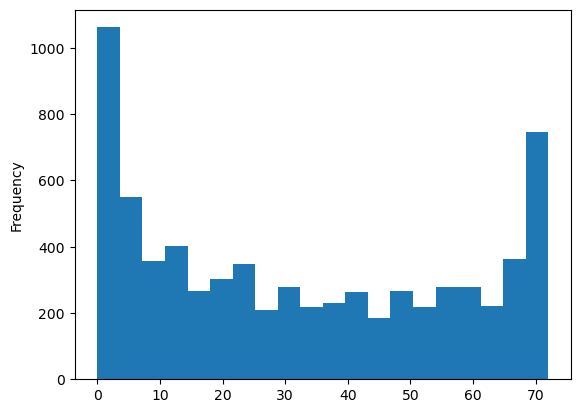

In [27]:
df_new['tenure'].plot(kind='hist',bins=20)

<Axes: ylabel='Density'>

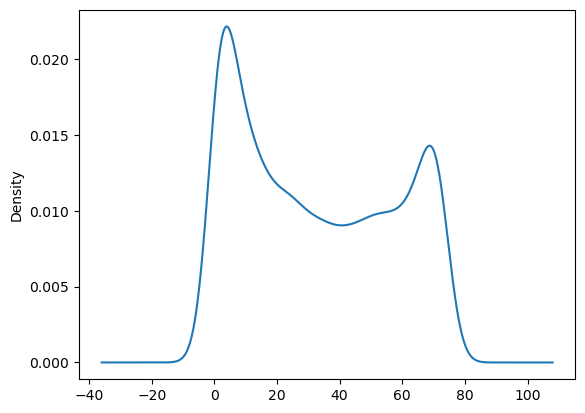

In [28]:
df_new['tenure'].plot(kind='kde')

In [29]:
df_new['tenure'].skew()

np.float64(0.2395397495619829)

<Axes: >

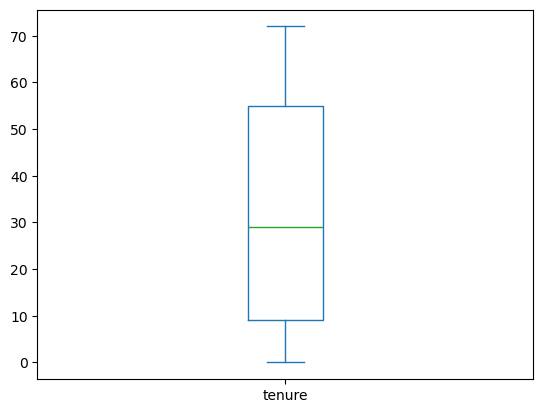

In [30]:
df_new['tenure'].plot(kind='box')

In [31]:
df_new['tenure'].isnull().sum()*100/len(df_new)

np.float64(0.0)

#### Conclusion -1) The average tenure is 32 months, but it varies a lot (std ≈ 24.5). 2)Half of the customers stay less than 29 months. 3)25% stay less than 9 months, while 25% stay more than 55 months. 4) There are no outliers and no missing values . 5) Tenure column is slight positive skewed


In [32]:
# MonthlyCharges column
df_new['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

<Axes: ylabel='Frequency'>

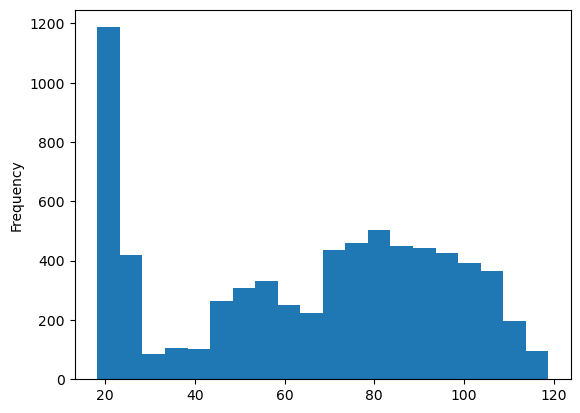

In [33]:
# Visualization
df_new['MonthlyCharges'].plot(kind='hist',bins=20)

<Axes: ylabel='Density'>

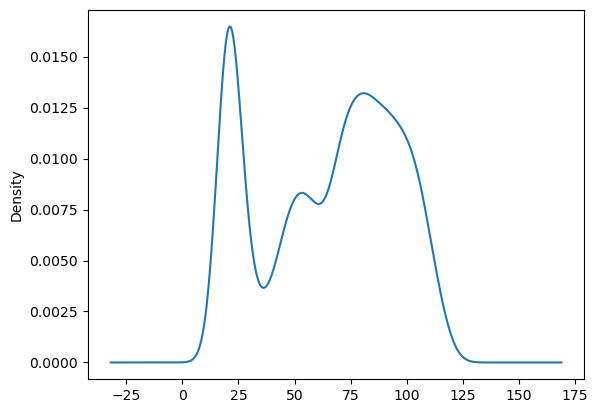

In [34]:
df_new['MonthlyCharges'].plot(kind='kde')

<Axes: >

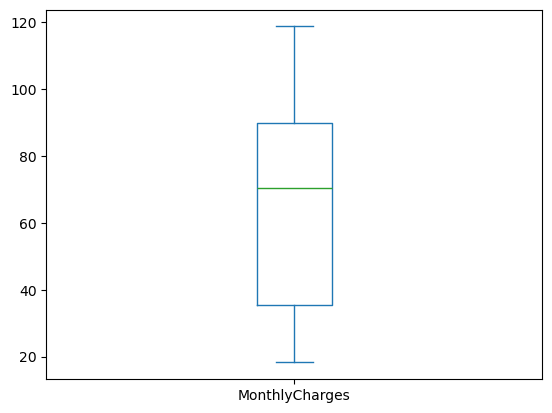

In [35]:
df_new['MonthlyCharges'].plot(kind='box')

In [36]:
df_new['MonthlyCharges'].skew()

np.float64(-0.22052443394398033)

In [37]:
df_new['MonthlyCharges'].isnull().sum()*100/len(df_new)

np.float64(0.0)

#### Conclusion- 1)The average charge is about 64.76, with std of 30.09, showing wide variation. 2)Charges range from 18.25 (minimum) to 118.75 (maximum).3)The median (50%) is 70.35, which is slightly higher than the mean, suggesting a skew toward lower charges.4) NO outliers n no missing values 5) Col is Left skewed.

In [38]:
df_new['TotalCharges'].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

<Axes: ylabel='Frequency'>

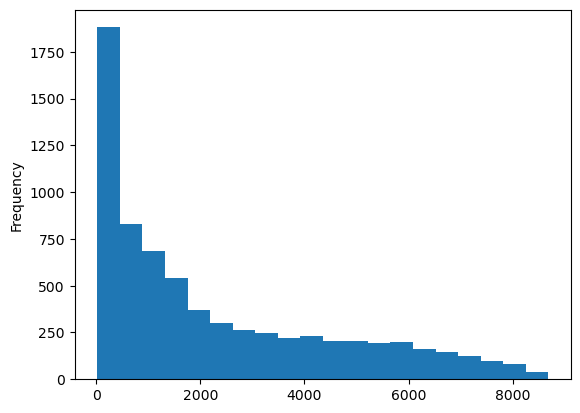

In [39]:
# Visualization
df_new['TotalCharges'].plot(kind='hist',bins=20)

<Axes: ylabel='Density'>

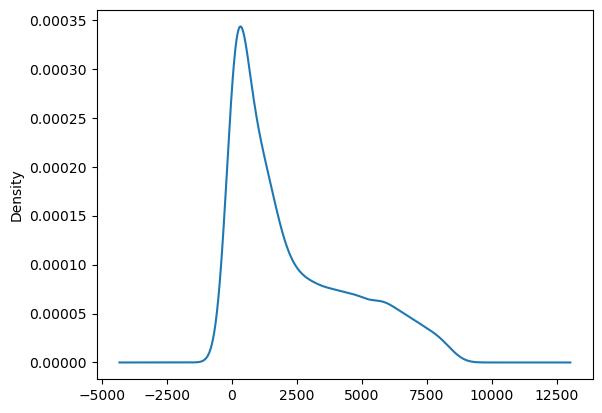

In [40]:
df_new['TotalCharges'].plot(kind='kde')

<Axes: >

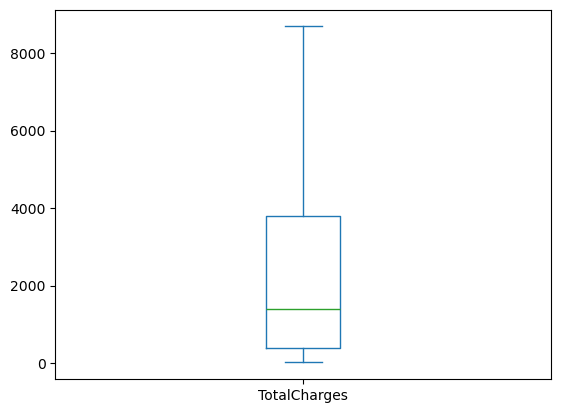

In [41]:
df_new['TotalCharges'].plot(kind='box')

In [42]:
df_new['TotalCharges'].skew()

np.float64(0.961642499724251)

In [43]:
df_new['TotalCharges'].isnull().sum()*100/len(df_new)

np.float64(0.15618344455487718)

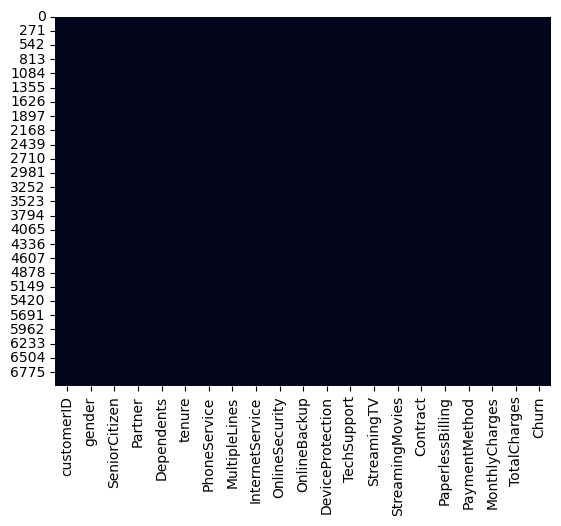

In [44]:
# Visualize missing values  but yaha all dark h missing values bhot kam h so dikh nai rhi h ...
sns.heatmap(df_new.isnull(),cbar = False)
plt.show()

In [45]:
df_new['TotalCharges'].fillna(df_new['TotalCharges'].median(),inplace=True)

In [46]:
df_new['TotalCharges'].isnull().sum()

np.int64(0)

#### Conclusion- 1) Mean (2283.30): Average total charges across customers.2) Std (2266.77): Very high variation, meaning customers differ widely in how much they’ve paid overall.3) Min (18.80): Lowest total charge. 4)25% (401.45): A quarter of customers have paid less than this. 5)50% (1397.48): Median total charge.6)75% (3794.74): Three-quarters of customers have paid less than this.7) No outliers n missing values 8) It is medium positive skewed.

In [47]:
#### Univariate Analysis on Categorical Data like gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn

In [48]:
df_new.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [49]:
# Performing analysis on gender column
df_new['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

<Axes: xlabel='gender'>

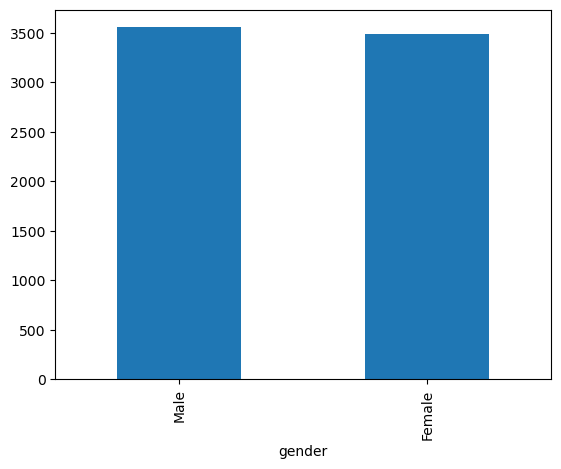

In [50]:
# Visualization 
df_new['gender'].value_counts().plot(kind='bar')

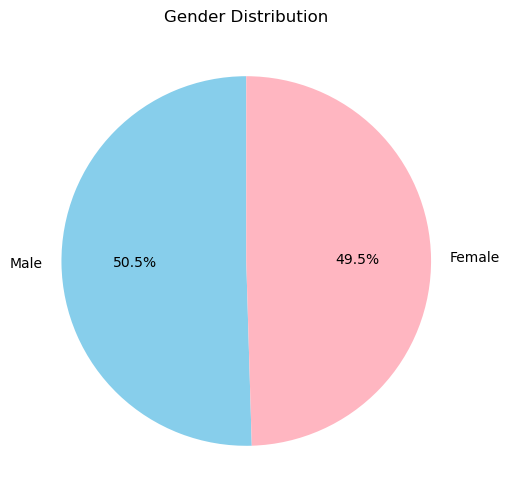

In [51]:
# df['gender'].value_counts().plot(kind='pie',autopct='%0.1f%')
df_new['gender'].value_counts().plot(
    kind='pie',
    autopct='%0.1f%%',
    figsize=(6,6),
    startangle=90,
    colors=['skyblue','lightpink']
)

plt.title("Gender Distribution")
plt.ylabel("")  # hides the y-axis label
plt.show()

In [52]:
df_new['gender'].isnull().sum()

np.int64(0)

#### Conclusion- 1) Male n Female are almost both in equal no. 2) No missing value in this column

In [53]:
df_new['Partner'].value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

<Axes: xlabel='Partner'>

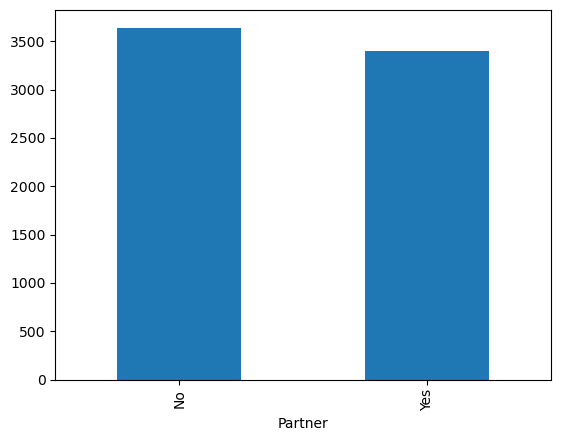

In [54]:
df_new['Partner'].value_counts().plot(kind='bar')

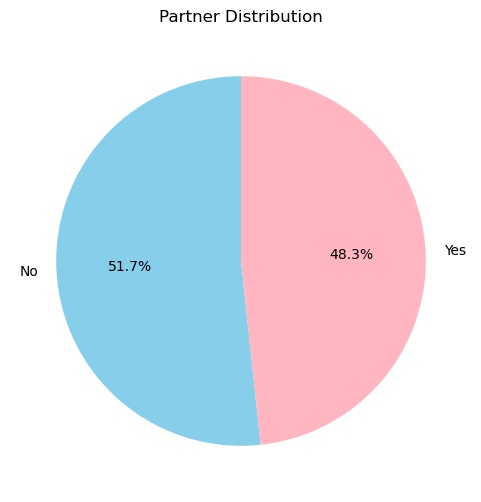

In [55]:
df_new['Partner'].value_counts().plot(kind='pie',autopct='%0.1f%%',figsize=(6,6), startangle=90,colors=['skyblue','lightpink']
)

plt.title("Partner Distribution")
plt.ylabel("")  # hides the y-axis label
plt.show()

In [56]:
df_new['Partner'].isnull().sum()

np.int64(0)

#### Conclusion- 1)No missing values 2) Values are equally balanced

In [57]:
df_new['Dependents'].value_counts()

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

<Axes: xlabel='Dependents'>

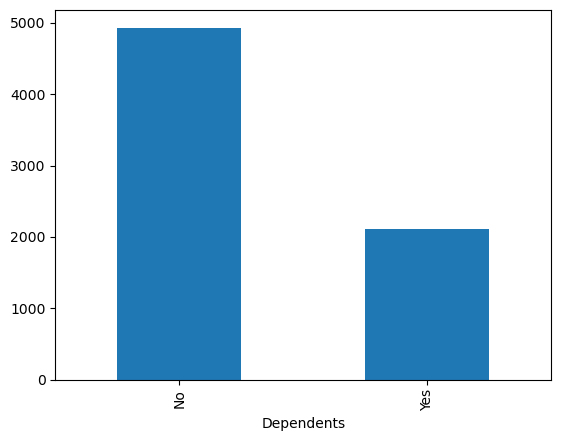

In [58]:
df_new['Dependents'].value_counts().plot(kind='bar')

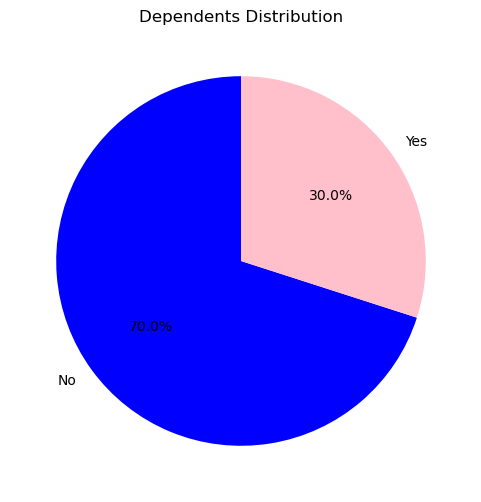

In [59]:
df_new['Dependents'].value_counts().plot(
    kind='pie',
     autopct='%0.1f%%',
     figsize=(6,6),
     startangle=90,
     colors=['blue','pink']
)
plt.title("Dependents Distribution")
plt.ylabel('')
plt.show()



In [60]:
df_new['Dependents'].isnull().sum()

np.int64(0)

#### Conclusion - No missing values n this column is imbalance bcoz yes values are 2110 n NO vlaues are 4933 but as this is not target column we wont do anything .

In [61]:
df_new['PhoneService'].value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

<Axes: xlabel='PhoneService'>

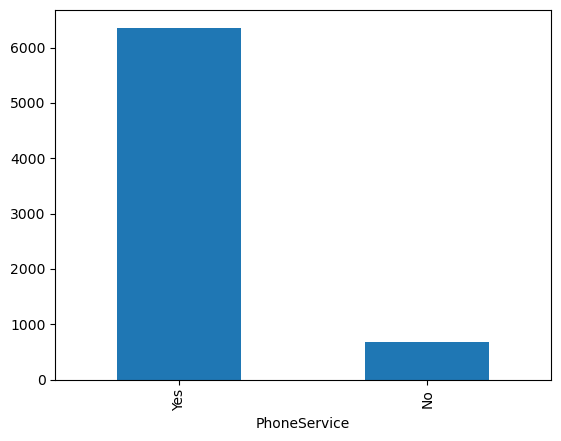

In [62]:
df_new['PhoneService'].value_counts().plot(kind='bar')

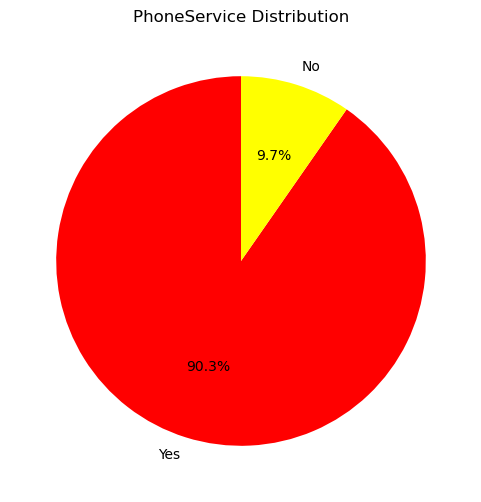

In [63]:
df_new['PhoneService'].value_counts().plot(
    kind='pie',
    autopct="%0.1f%%",
    figsize=(6,6),
    startangle=90,
    colors=['red','yellow']
)
plt.title("PhoneService Distribution")
plt.ylabel("")
plt.show()

    

In [64]:
df_new['PhoneService'].isnull().sum()

np.int64(0)

#### Conclusion- NO missing values but column is imbalance but this wont effect bcoz this is not target class

In [65]:
df_new['MultipleLines'].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

<Axes: xlabel='MultipleLines'>

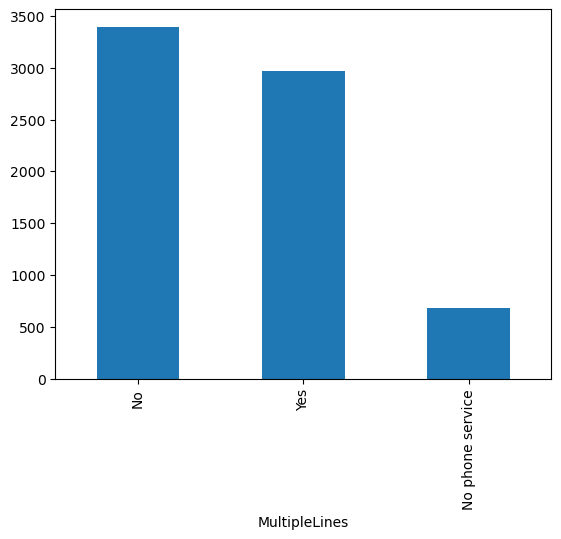

In [66]:
df_new['MultipleLines'].value_counts().plot(kind='bar')

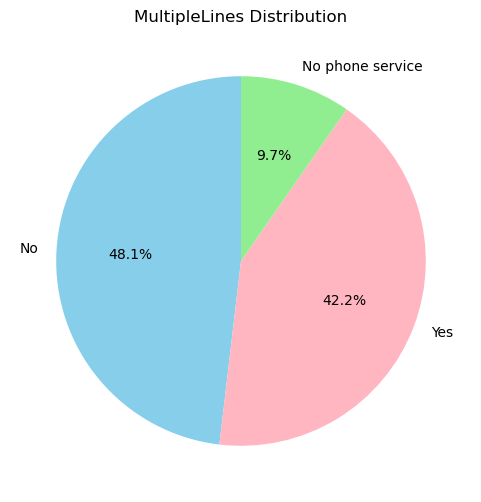

In [67]:
df_new['MultipleLines'].value_counts().plot(
    kind='pie',
    autopct='%0.1f%%',
    figsize=(6,6),
    startangle=90,
    colors=['skyblue','lightpink','lightgreen']
    )
plt.title("MultipleLines Distribution")
plt.ylabel("")
plt.show()

In [68]:
df_new['MultipleLines'].isnull().sum()

np.int64(0)

#### Conclusion- NO missing values but column is imbalance but this wont effect bcoz this is not target class

In [69]:
df_new['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

<Axes: xlabel='InternetService'>

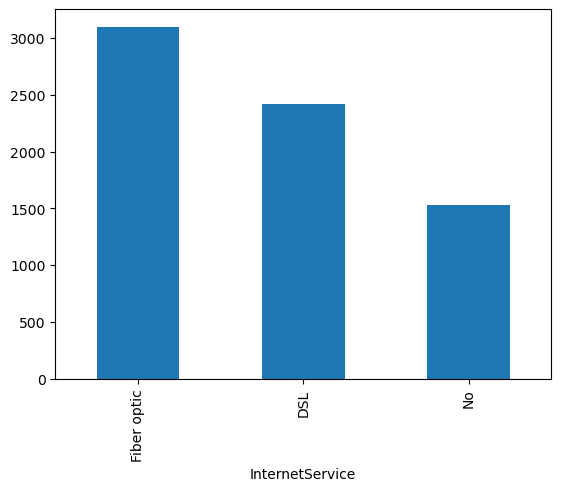

In [70]:
df_new['InternetService'].value_counts().plot(kind='bar')

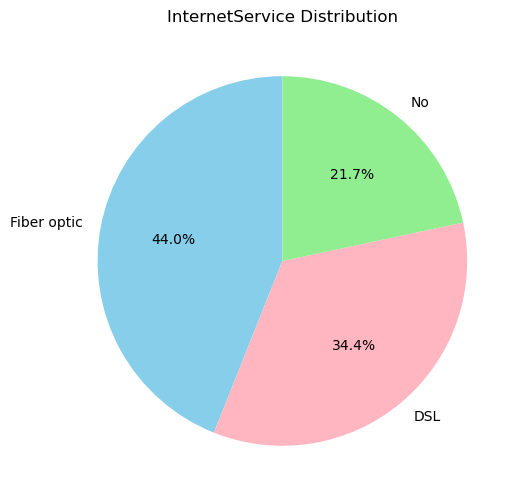

In [71]:
df_new['InternetService'].value_counts().plot(
    kind='pie',
    autopct='%0.1f%%',
    figsize=(6,6),
    startangle=90,
    colors=['skyblue','lightpink','lightgreen']
    )
plt.title("InternetService Distribution")
plt.ylabel("")
plt.show()

In [72]:
df_new['InternetService'].isnull().sum()

np.int64(0)

#### Conclusion- People using fiberoptic are more than DSL and the person who are not using any service 2) There are no missing values

In [73]:
df_new['OnlineSecurity'].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

<Axes: xlabel='OnlineSecurity'>

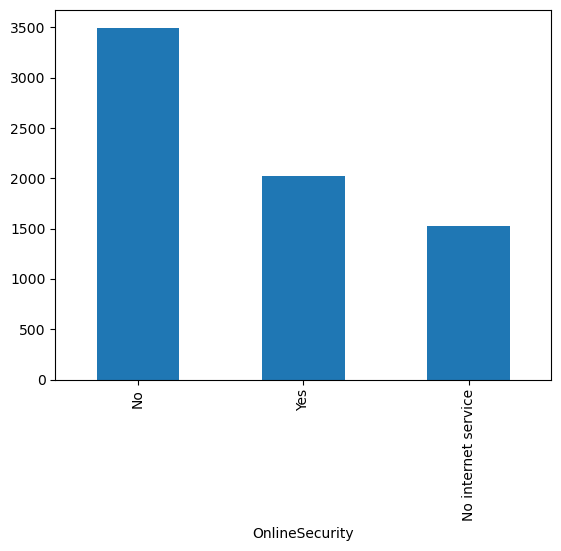

In [74]:
df_new['OnlineSecurity'].value_counts().plot(kind='bar')

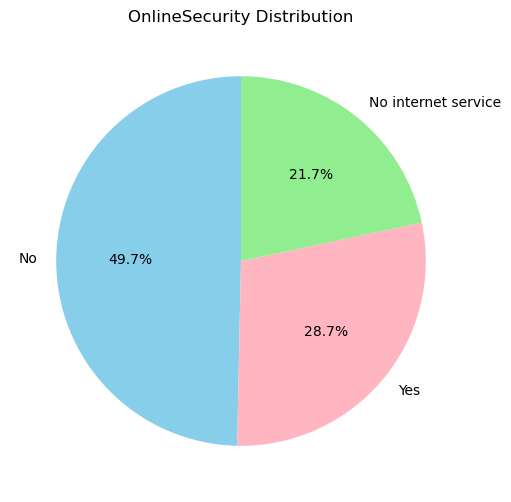

In [75]:
df_new['OnlineSecurity'].value_counts().plot(
    kind='pie',
    autopct='%0.1f%%',
    figsize=(6,6),
    startangle=90,
    colors=['skyblue','lightpink','lightgreen']
    )
plt.title("OnlineSecurity Distribution")
plt.ylabel("")
plt.show()

In [76]:
df_new['OnlineSecurity'].isnull().sum()

np.int64(0)

#### Conclusion- 

In [77]:
df_new.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [78]:
# Performing EDA on remaining categorical column together
cols=['OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod','Churn']
df_categorical=df_new[cols]

In [79]:
# Value Counts
for col in cols:
    print(f"\nValue counts for {col}:")
    print(df_new[col].value_counts().to_string())
    print('***************************')


Value counts for OnlineBackup:
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
***************************

Value counts for DeviceProtection:
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
***************************

Value counts for TechSupport:
TechSupport
No                     3473
Yes                    2044
No internet service    1526
***************************

Value counts for StreamingTV:
StreamingTV
No                     2810
Yes                    2707
No internet service    1526
***************************

Value counts for StreamingMovies:
StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
***************************

Value counts for Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
***************************

Value counts for PaperlessBilling:
PaperlessBilling
Yes    4171
No    

# Visualization 

plt.figure(figsize=(15,12))
for i,col in enumerate (cols):
    plt.subplot(3,3,i+1)
    df[col].value_counts().plot(kind='bar')
    plt.title(col,fontsize=10,pad=10)
    plt.xticks(rotation=90,fontsize=10)

plt.tight_layout(pad=5.0)
plt.show()

In [80]:
# Missing values
df_new[cols].isnull().sum()*100/len(df_new[cols])

OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
Churn               0.0
dtype: float64

#### Conclusion - 1)OnlineBackup - Majority of customer dont use online backup service so churn risk is more 2)DeviceProtection- Same here less no. of customer use device protection to protect their laptop/pc so more chances of customer churn 3) Most of the customer are not taking Technical support so there problems are not solved so high chances of churn 4)StreamingTV and StreamingMovies - Data yes n No almost balanced h so very less chances of churn here.5)Contract-> <span style="color:red">Month-to-month -3875 (This no. of people has taken plan month-to month so they can cancel it any time if month is completed so here chances of churn are more.</span>Two year->1695( Ye term plan long tern h i.e customers cant leave so they wont churn so low churn n same for one year plan 6)PaperlessBilling- Yes -> 4171, No -> 2872 . Here people using online billing is more that means people can easily switch to service bcoz its online so multiple option available so<span style="color:red"> high chances of churn </span> 7) PaymentMethod- Electronic check so Online payment so <span style="color:red"> More churn > </span> Mailed check - Check se payment so less churn lasy 2 are automatiic so customer dont have to do anything so less churn .



In [81]:
df_new['Churn'].unique()

array(['No', 'Yes'], dtype=object)

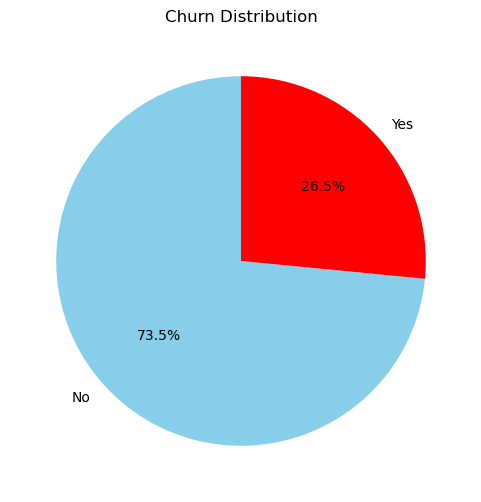

In [82]:
df_new['Churn'].value_counts().plot(
    kind='pie',
    autopct ='%0.1f%%',
    figsize=(6,6),
    startangle=90,
    colors=['skyblue','red'])
plt.title("Churn Distribution")
plt.ylabel("")
plt.show()

#### Conclusion- 26.5 % customer has left so so we need to look after that by providing better services, long term contracts n we need to improve customer support also.

#### Conclusion- Need to apply feature engineering on column which has NO and No Internet Service .

#### <span style = "color:red ">Bivariate Analysis </span>

In [83]:
df_new.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [84]:
df_new.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [85]:
pd.crosstab(df_new['Churn'],df_new['gender'],normalize='index')*100

gender,Female,Male
Churn,,
No,49.265559,50.734441
Yes,50.240770,49.759230


#### <span style="color :red"> Conclusion - Male n Female are almost equal in both churn n No churn so gender has no effect on Customer Churn </span> 

In [86]:
pd.crosstab(df_new['Churn'],df_new['SeniorCitizen'],normalize='index')*100

SeniorCitizen,0,1
Churn,,
No,87.127947,12.872053
Yes,74.531835,25.468165


#### <span style="color:red"> Adult Non churn h 87% and wo decrease hua churn me i.e 74% and Senior cetizen non churn me 13% h n wo churn me increase hua 25% so Senior cetizen are more likely to churn</span>

In [87]:
pd.crosstab(df_new['Churn'],df_new['Partner'],normalize='index')*100

Partner,No,Yes
Churn,,
No,47.178199,52.821801
Yes,64.205457,35.794543


#### <span style= "color:red">Conclusion- Customers who have partners are more likely to not churn .

In [88]:
pd.crosstab(df_new['Churn'],df_new['Dependents'],normalize='index')*100

Dependents,No,Yes
Churn,,
No,65.519907,34.480093
Yes,82.557517,17.442483


#### <span style ="color: red" >Customers those who dont have dependent are more likely to churn i.e Dependents presence reduces churn probability.</span>

In [89]:
pd.crosstab(df_new['Churn'],df_new['tenure'],normalize='index')*100

tenure,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72
Churn,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
No,0.212601,4.503286,2.222652,2.048705,1.797449,1.333591,1.352918,1.546193,1.565520,1.410901,1.372246,1.314264,1.526865,1.372246,1.005025,1.198299,1.005025,1.178972,1.410901,1.043680,1.024353,0.889061,1.217627,1.391573,1.372246,1.082335,1.236954,1.140317,0.869733,1.101662,1.082335,0.947043,0.966370,0.966370,1.024353,1.410901,0.773096,0.966370,0.889061,0.811751,0.985698,1.082335,0.985698,0.966370,0.869733,1.063007,1.198299,1.043680,1.063007,0.985698,1.120990,1.159644,1.391573,1.082335,1.063007,1.063007,1.352918,1.101662,1.082335,1.005025,1.352918,1.314264,1.256281,1.314264,1.468883,1.294936,1.468883,1.700812,1.758794,1.681484,2.08736,3.169695,6.880557
Yes,0.000000,20.331728,6.581059,5.029428,4.440877,3.424291,2.140182,2.728732,2.247191,2.461209,2.407705,1.658641,2.033173,2.033173,1.284109,1.979668,1.498127,1.391118,1.284109,1.016586,0.963082,0.909577,1.444623,0.695559,1.230605,1.230605,0.802568,0.695559,0.642055,0.802568,0.856073,0.856073,1.016586,0.749064,0.642055,0.802568,0.535045,0.802568,0.695559,0.749064,0.695559,0.749064,0.749064,0.802568,0.321027,0.321027,0.642055,0.749064,0.481541,0.802568,0.535045,0.428036,0.428036,0.749064,0.695559,0.481541,0.535045,0.428036,0.588550,0.428036,0.321027,0.428036,0.267523,0.214018,0.214018,0.481541,0.695559,0.535045,0.481541,0.428036,0.58855,0.321027,0.321027


<Axes: xlabel='Churn', ylabel='tenure'>

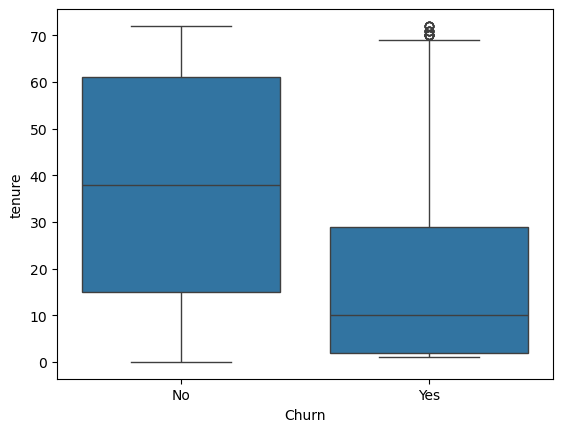

In [90]:
# Churn n Tenure column analysis
sns.boxplot(x='Churn',y='tenure',data=df_new)

<Axes: xlabel='tenure', ylabel='Density'>

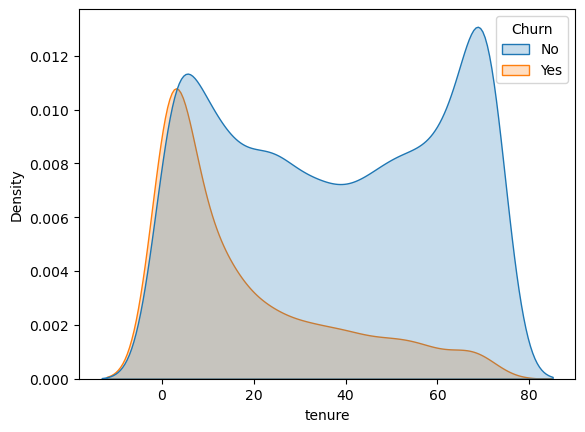

In [91]:
sns.kdeplot(data=df_new,x='tenure',hue='Churn',fill=True)

#### Conclusion-  Here Churn =Yes has high peak at lower value i.e between 0-10 n churn =No has high peak at higher value i.65-70 so it means customer with low tenure are more likely to churn and Box plot where  churn = No  median value is 35-40 i.e customer are from long term i.e from 34-40 month and low median i.e churn =yes have low tenure 10-12 month so some customer left after 10-12 months.

In [92]:
#### Churn n PhoneService
pd.crosstab(df_new['Churn'],df_new['PhoneService'],normalize='index')*100

PhoneService,No,Yes
Churn,,
No,9.895632,90.104368
Yes,9.095773,90.904227


#### <span style='color: red'> Values of PhoneService are almost same for yes n no churn values so PhoneService do not give any impact on Churn </span>

In [93]:
# Churn n Multiple lines
pd.crosstab(df_new['Churn'],df_new['MultipleLines'],normalize='index')*100

MultipleLines,No,No phone service,Yes
Churn,,,
No,49.110939,9.895632,40.993429
Yes,45.425361,9.095773,45.478866


#### <span style= "color: red"> MultipleLines does not have a significant impact on churn , as distribution is similar across all categories. So multiple lines hone ya na hone se churn pe koi effect nai padh rha . </span>

In [94]:
# Churn n InternetService
pd.crosstab(df_new['Churn'],df_new['InternetService'],normalize='index')*100

InternetService,DSL,Fiber optic,No
Churn,,,
No,37.920371,34.770004,27.309625
Yes,24.558587,69.395399,6.046014


<Axes: xlabel='InternetService', ylabel='Churn'>

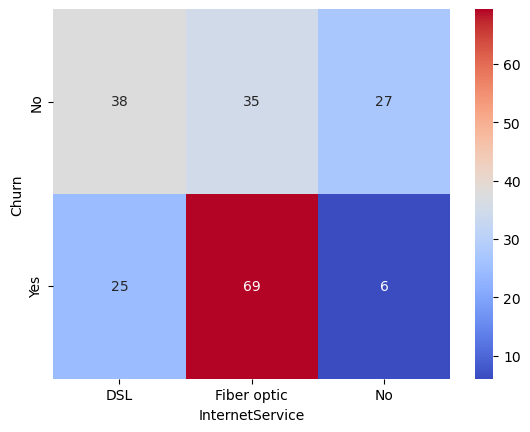

In [95]:
ci= pd.crosstab(df_new['Churn'],df_new['InternetService'],normalize='index')*100
sns.heatmap(ci,annot=True,cmap='coolwarm')

#### Conclusion - Customers using Fiber optics have higher Churn Tendency

In [96]:
# Churn n OnlineSecurity
pd.crosstab(df_new['Churn'],df_new['OnlineSecurity'],normalize='index')*100

OnlineSecurity,No,No internet service,Yes
Churn,,,
No,39.369927,27.309625,33.320448
Yes,78.170144,6.046014,15.783842


<Axes: xlabel='OnlineSecurity', ylabel='Churn'>

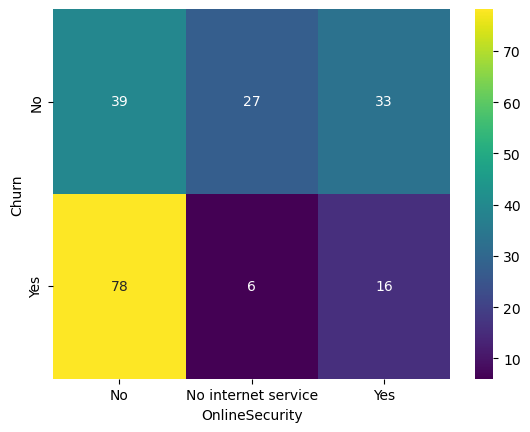

In [97]:
co=pd.crosstab(df_new['Churn'],df_new['OnlineSecurity'],normalize='index')*100
sns.heatmap(co,annot=True,cmap='viridis')

#### Customers who donts have internet service are more likely to churn

In [98]:
pd.crosstab(df_new['Churn'],df_new['OnlineBackup'],normalize='index')*100

OnlineBackup,No,No internet service,Yes
Churn,,,
No,35.852339,27.309625,36.838036
Yes,65.971108,6.046014,27.982879


<Axes: xlabel='OnlineBackup', ylabel='Churn'>

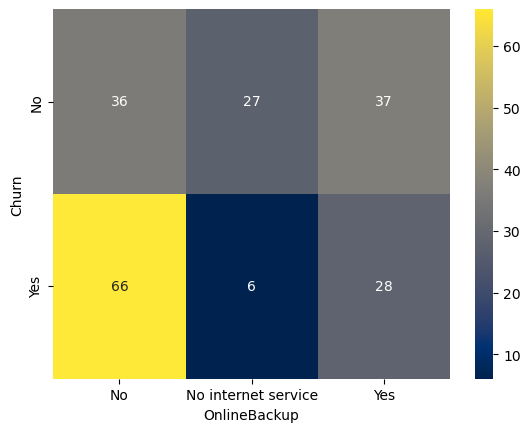

In [99]:
cb=pd.crosstab(df_new['Churn'],df_new['OnlineBackup'],normalize='index')*100
sns.heatmap(cb,annot=True,cmap='cividis')

#### Conclusion- Same as above

In [100]:
pd.crosstab(df_new['Churn'],df_new['DeviceProtection'],normalize='index')*100

DeviceProtection,No,No internet service,Yes
Churn,,,
No,36.412833,27.309625,36.277542
Yes,64.794007,6.046014,29.159979


<Axes: xlabel='DeviceProtection', ylabel='Churn'>

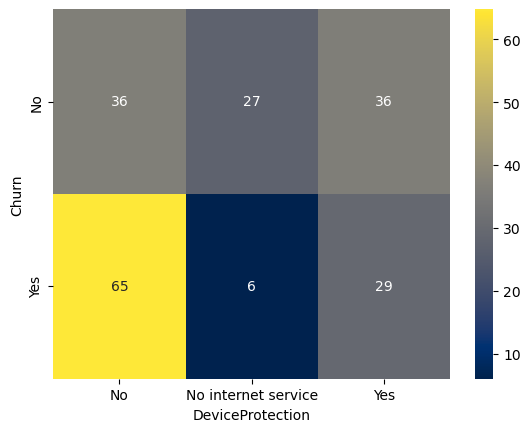

In [101]:
cd=pd.crosstab(df_new['Churn'],df_new['DeviceProtection'],normalize='index')*100
sns.heatmap(cd,annot=True,cmap='cividis')

#### Conclusion - Same as above

In [102]:
pd.crosstab(df_new['Churn'],df_new['TechSupport'],normalize='index')*100

TechSupport,No,No internet service,Yes
Churn,,,
No,39.176652,27.309625,33.513722
Yes,77.367576,6.046014,16.586410


<Axes: xlabel='TechSupport', ylabel='Churn'>

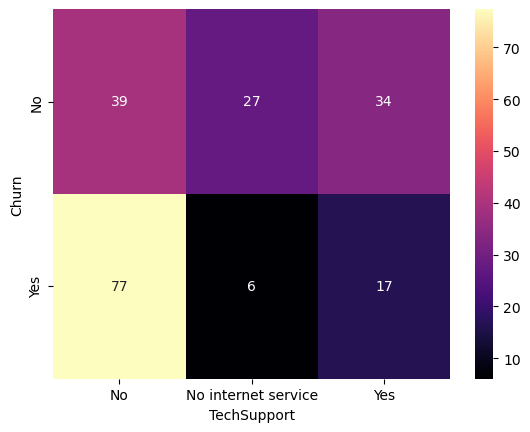

In [103]:
ct=pd.crosstab(df_new['Churn'],df_new['TechSupport'],normalize='index')*100
sns.heatmap(ct,annot=True,cmap='magma')

#### Conclusion- Same as above

In [104]:
pd.crosstab(df_new['Churn'],df_new['StreamingTV'],normalize='index')*100

StreamingTV,No,No internet service,Yes
Churn,,,
No,36.103595,27.309625,36.586780
Yes,50.401284,6.046014,43.552702


<Axes: xlabel='StreamingTV', ylabel='Churn'>

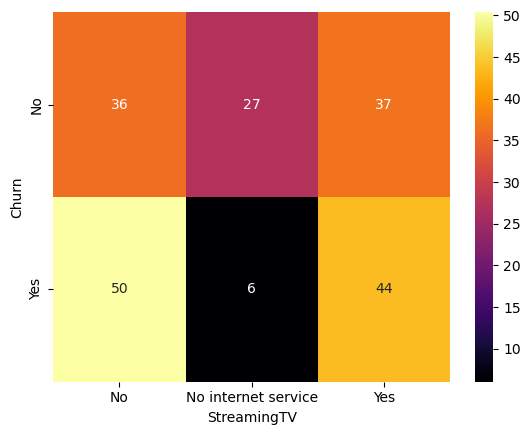

In [105]:
cs= pd.crosstab(df_new['Churn'],df_new['StreamingTV'],normalize='index')*100
sns.heatmap(cs,annot=True,cmap='inferno')

#### Conclusion- StreamingTv has no effect on Churn bcoz Yes n No churn  values for Streamin Tv are almost similar are 

In [106]:
pd.crosstab(df_new['Churn'],df_new['StreamingMovies'],normalize='index')*100

StreamingMovies,No,No internet service,Yes
Churn,,,
No,35.697719,27.309625,36.992656
Yes,50.187266,6.046014,43.766720


<Axes: xlabel='StreamingMovies', ylabel='Churn'>

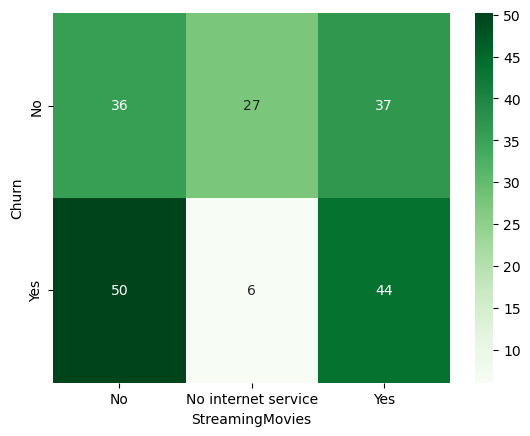

In [107]:
cm= pd.crosstab(df_new['Churn'],df_new['StreamingMovies'],normalize='index')*100
sns.heatmap(cm,annot=True,cmap='Greens')

#### Conclusion- Same as above

In [108]:
pd.crosstab(df_new['Churn'],df_new['Contract'],normalize='index')*100

Contract,Month-to-month,One year,Two year
Churn,,,
No,42.906842,25.260920,31.832238
Yes,88.550027,8.881755,2.568218


<Axes: xlabel='Contract', ylabel='Churn'>

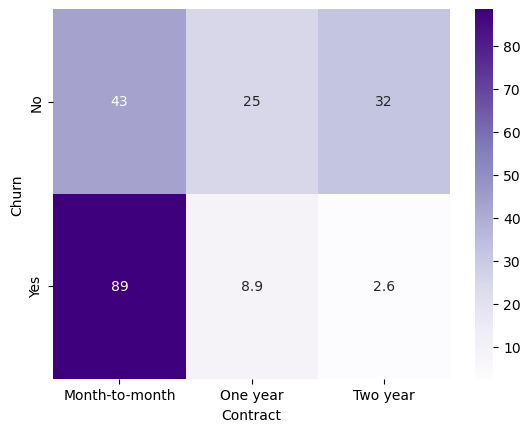

In [109]:
cc=pd.crosstab(df_new['Churn'],df_new['Contract'],normalize='index')*100
sns.heatmap(cc,annot=True,cmap='Purples')

#### Conclusion- Month-month customers are having more churn rate than Long term customers . So Contract column influence more toward churn

In [110]:
pd.crosstab(df_new['Churn'],df_new['PaperlessBilling'],normalize='index')*100

PaperlessBilling,No,Yes
Churn,,
No,46.443757,53.556243
Yes,25.093633,74.906367


<Axes: xlabel='PaperlessBilling', ylabel='Churn'>

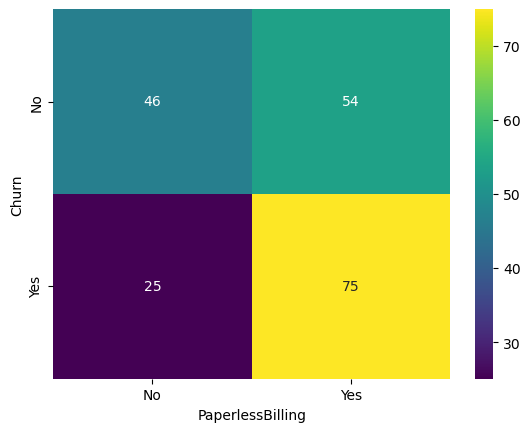

In [111]:
cpl=pd.crosstab(df_new['Churn'],df_new['PaperlessBilling'],normalize='index')*100
sns.heatmap(cpl,annot=True,cmap='viridis')

#### Conclusion- Customer with Paperless Biling are more likely to churn ..it is possible that they switch services more .

In [112]:
pd.crosstab(df_new['Churn'],df_new['PaymentMethod'],normalize='index')*100

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Churn,,,,
No,24.855044,24.932354,25.009664,25.202938
Yes,13.804173,12.413055,57.303371,16.479401


<Axes: xlabel='PaymentMethod', ylabel='Churn'>

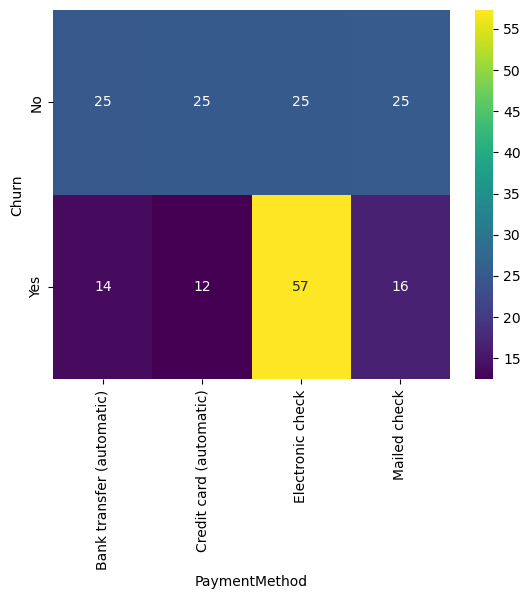

In [113]:
cpm=pd.crosstab(df_new['Churn'],df_new['PaymentMethod'],normalize='index')*100
sns.heatmap(cpm,annot=True,cmap='viridis')

#### Conclusion- Customers using Electronic check method are tend to more churn bcoz its like they have to manually do payment using netbanking, upi method.

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

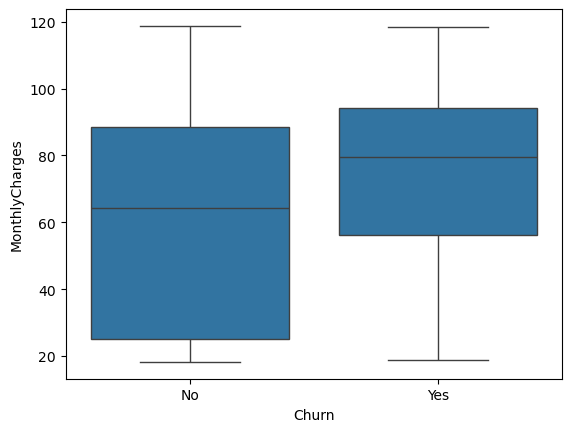

In [114]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df_new)

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

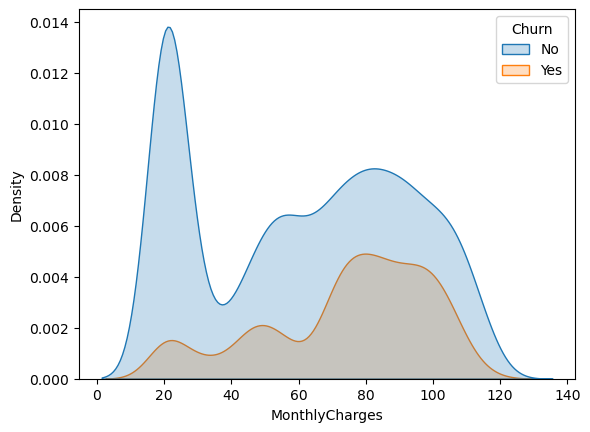

In [115]:
sns.kdeplot(data=df_new,x='MonthlyCharges',hue='Churn',fill=True)

#### Conclusion- In box plot for No churn customers median value is 65 and for customers where churn is YES median value is 80 .So High monthly bills customers churn more

#### Conclusion- In KDE plot Yes churn customer peak value is between 70-80 and No churn customer peak value is between 0-20. This show high monthly charges customers churn more .

<Axes: xlabel='Churn', ylabel='TotalCharges'>

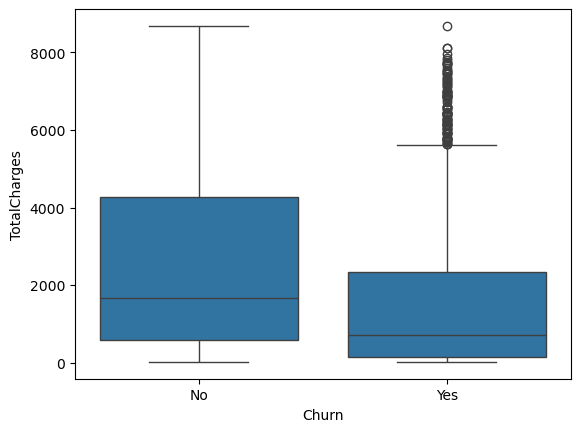

In [116]:
sns.boxplot(data=df_new,x='Churn',y='TotalCharges')

<Axes: xlabel='TotalCharges', ylabel='Density'>

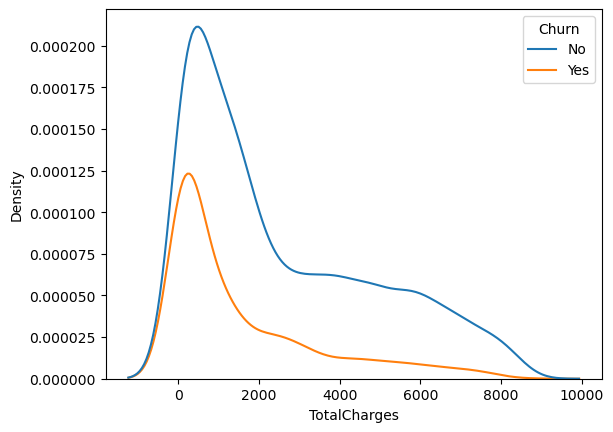

In [117]:
sns.kdeplot(data=df_new,x="TotalCharges",hue='Churn')

#### Conclusion- LOw charges paying customer are churning more while long term customer are staying n paynig more charges.

#### <span style= "color:red"> Feature Engineering on columns </span>

In [118]:
df_new.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [119]:
df_new.drop('customerID',axis=1,inplace=True)

In [120]:
df_new.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [121]:
df_new.isnull().sum()/len(df_new)*100

gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

In [123]:
df_new['Churn']=df_new['Churn'].astype(str).str.strip().str.capitalize()
df_new['Churn']=df_new['Churn'].replace({'Yes':1,'No':0})
df_new = pd.get_dummies(df_new, drop_first=True)

df_new.select_dtypes(include='object').columns

Index([], dtype='object')

<h4 style="color:Blue">Applying Models</h4>


In [129]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from imblearn.over_sampling import SMOTE

In [130]:
X = df_new.drop('Churn', axis=1)
y = df_new['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [131]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

# <span style="color:red">Logistic Regression </span>


In [132]:
lr = LogisticRegression()
lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test_scaled)

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

LR Accuracy: 0.7381121362668559
[[742 293]
 [ 76 298]]
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



# <span style="color:red">Random Forest </span>

In [136]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 0.7863733144073811
[[924 111]
 [190 184]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409



In [138]:
importance=rf.feature_importances_

# Create Dataframe
feat_imp=pd.DataFrame({
    'Feature':X_train.columns,
    'Importance':importance
})
# Sorting 
feat_imp=feat_imp.sort_values(by='Importance',ascending=False)

# Top 10 features
print(feat_imp.head(10))

                           Feature  Importance
3                     TotalCharges    0.192096
1                           tenure    0.174733
2                   MonthlyCharges    0.168413
28  PaymentMethod_Electronic check    0.038771
10     InternetService_Fiber optic    0.038641
25               Contract_Two year    0.030176
4                      gender_Male    0.028321
13              OnlineSecurity_Yes    0.028191
26            PaperlessBilling_Yes    0.025617
5                      Partner_Yes    0.023326


# Insights

### 1) The model shows that pricing and customer duration are the most critical factors influencing churn. 
### 2) Customers who are new or paying higher monthly charges are more likely to leave.
### 3) Service- related factors like internet type and payment method also impact churn,while long-term contracts and additional services help in      retaining customers.    